# Entendiendo los LLMs

## ¿Qué es un LLMs?

Imagina que la biblioteca tiene millones de libros. El LLM los leyó todos durante su entrenamiento. Ahora, cuando le escribes algo, no "busca" el libro — ya internalizó las relaciones entre palabras. Sabe que "rey" se relaciona con "trono", "corona", "poder", igual que "chef" se relaciona con "cocina", "cuchillo", "receta".

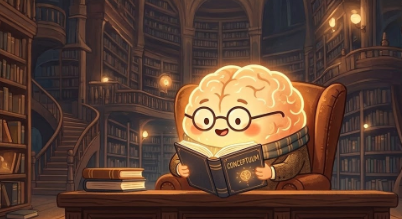

Un LLM pertenece al campo del NLP (Procesamiento
del Lenguaje Natural), que a su vez está construido
sobre Deep Learning usando redes profundas llamadas
Transformers. Y adopta IA Generativa como capacidad
porque puede generar texto, código e imágenes.

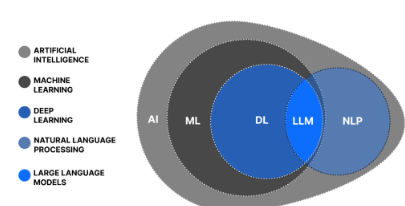

### Parte de tokenización

El LLM necesita cortar tu texto en pedazos manejables a eso se le llama tokenización.

Utilizando Tiktokenizar veremos como corta en español y en inglés.
https://tiktokenizer.vercel.app/

Algo importantes escribir en inglés cuesta menos tokens.

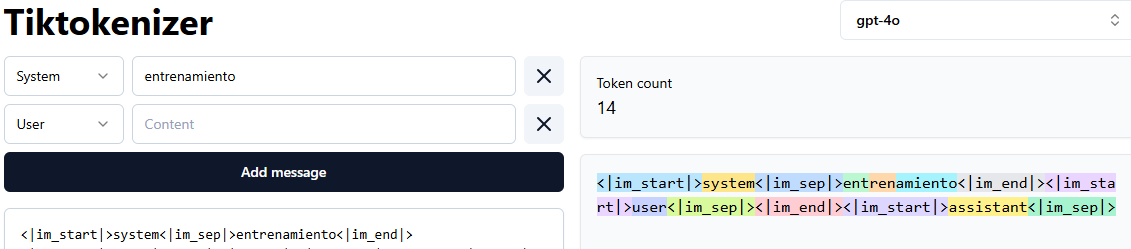

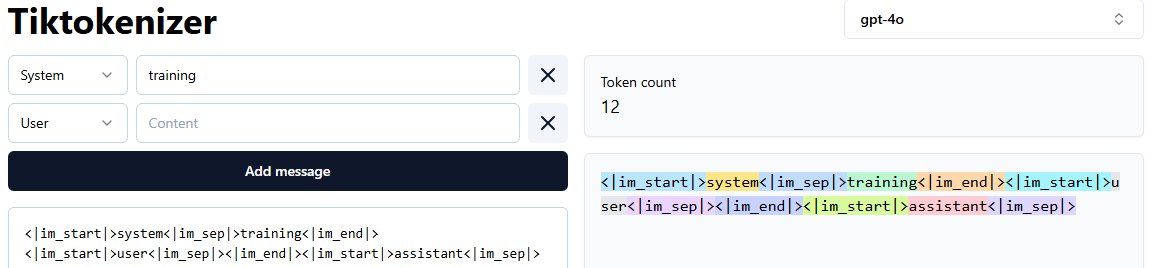

In [ ]:
!pip install tiktoken

In [ ]:
!pip install -q google-generativeai

In [ ]:
!pip install -U google-genai

In [ ]:
!pip install pymupdf

In [ ]:
import tiktoken
import google.generativeai as genai
from getpass import getpass

In [ ]:
enc = tiktoken.encoding_for_model("gpt-4")

In [ ]:
text = "reino"
tokens = enc.encode(text)
print(tokens)

text = "reina"
tokens = enc.encode(text)
print(f"{tokens}")

[265, 3394]
[265, 2259]


Esa palabra cortado lo convierte en ID.

### Embedding

Luego el modelo entra al modelo Embedding y sale con un vector de coordenadas númericas.

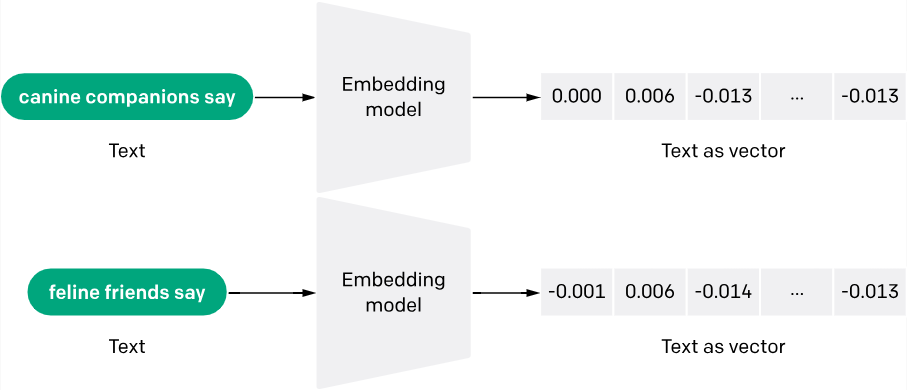

In [ ]:
API_KEY = getpass("Ingresa tu API KEY ..")
genai.configure(api_key=API_KEY)

Ingresa tu API KEY ..··········


In [ ]:
for m in genai.list_models():
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025
models/gemini-embedding-001
models/gemini-embedding-2-

In [ ]:
result = genai.embed_content(
    model="models/gemini-embedding-001",
    content="rey"
)

print(result['embedding'])

[-0.0042064954, -0.013473824, 0.009054521, -0.07122485, 0.004371808, -0.021875845, 0.005446214, 0.0054974654, -0.0038959105, 0.004685483, 0.021851258, 0.0159271, -0.014300214, 0.032460637, 0.11182958, -0.002050202, 0.008978246, 0.0103462115, -0.0008804474, -0.0054185293, 0.018260954, -0.019635169, 0.020902675, 0.0037540346, -0.0056188125, 0.040624958, 0.027299859, -0.00036179283, 0.01909675, 0.029223014, -0.0005130983, -0.010287743, -0.008107466, 0.004378943, -0.024304712, -0.002639536, -0.0068190154, 0.012441541, 0.008983179, 0.0065327194, 0.007116407, -0.000605017, 0.039395288, -0.023461742, -0.009042317, -0.016831176, -0.0057622967, -0.039975736, -0.0026560496, 0.031743277, -0.010064989, -0.020055257, 0.015447477, -0.15946698, -0.016826684, 0.020856554, -0.00708383, 0.011629536, 0.02315609, -0.007411703, -0.004419763, 0.0049899407, -0.016655957, 0.0018877242, -0.028393338, 0.019292952, 0.015468607, 0.00751329, -0.00524003, 0.011913949, 0.0008187758, -0.029004682, -0.0051388443, 0.00

### Conceptos claves

- 🧱 Tokens: Piezas en que el modelo divide el texto. No lee palabras, lee tokens. También es la unidad con la que te cobran.
- 💰 Costes:
Pagas por cada token que el modelo procesa y genera. Más tokens = más caro.
- 🧠 Ventana de Contexto:
La memoria a corto plazo. Si la conversación es muy larga y se llena, el modelo empieza a olvidar lo que dijiste al inicio y puede alucinar.
- 👁️ Multimodalidad:
El modelo no solo lee texto — también puede ver imágenes, escuchar audio y analizar video.
- ⏱️ Latencia:
El tiempo entre que envías tu mensaje y el modelo responde el primer token.
- 🌀 Alucinaciones
Cuando el modelo no sabe algo y lo inventa con total confianza. Es su mayor defecto.
- Modelos rápidos    →  responden de inmediato
- Modelos razonadores →  pausan, planifican y verifican antes de responder
- Nube  →  más potente, pero tus datos salen fuera
- Local →  más privado para tus datos, sin costes de API

## Ingeniería de prompts

**Zero-Shot**: Darle una instucción sin proporcionar un ejemplo. Pero no va a dar la respuesta esperada ya que no sabe el contexto.

In [ ]:
import google.generativeai as genai

genai.configure(api_key=API_KEY)

model = genai.GenerativeModel("models/gemini-2.5-flash")

response = model.generate_content("""
Clasifica este mensaje como positivo o negativo.

Cineplanet, esto es inaceptable. Compré 2 entradas con la promo Yape y el
sistema indica que fueron canjeadas sin que yo las usara. Luego esas mismas
butacas aparecieron ocupadas por otras personas. Esto es una falla grave de
seguridad. ¿Cómo se canjean entradas sin autorización del usuario? Exijo una
explicación y una solución inmediata. Por mi ni una estrella le pongo.
""")
print(response.text)

Este mensaje es claramente **negativo**.

Expresa una experiencia muy insatisfactoria, frustración, enojo y una grave preocupación por un fallo de seguridad, terminando con una fuerte declaración de insatisfacción.


**Few-Shot Prompting (Con ejemplos)**: Esta técnica consiste en darle al modelo unos pocos ejemplos (generalmente de 2 a 5) de parejas de "pregunta y respuesta" o "entrada y salida" antes de presentarle la tarea real ayudando a la IA a entender el formato.

In [ ]:
import google.generativeai as genai

genai.configure(api_key=API_KEY)

model = genai.GenerativeModel("models/gemini-2.5-flash")

response = model.generate_content("""
Clasifica mensajes como positivo o negativo.

Ejemplos:
Mensaje: "Me encantó la atención, volveré pronto" → Positivo
Mensaje: "Pésimo servicio, nunca más regreso" → Negativo
Mensaje: "Excelente calidad, lo recomiendo" → Positivo
Mensaje: "Me cobraron de más y nadie me ayudó" → Negativo

Ahora clasifica:
Mensaje: "Cineplanet, esto es inaceptable. Compré 2 entradas con la promo
Yape y el sistema indica que fueron canjeadas sin que yo las usara. Luego
esas mismas butacas aparecieron ocupadas por otras personas. Esto es una
falla grave de seguridad. Exijo una explicación y una solución inmediata.
Por mi ni una estrella le pongo."
""")
print(response.text)

Negativo


**Chain-of-Thought (CoT - Cadena de pensamiento)**: Es una técnica diseñada para problemas que requieren lógica o varios pasos para resolverse. En lugar de pedirle a la IA solo la respuesta final, se le instruye para que muestre su razonamiento paso a paso para reducir errores en situaciones de lógica.

In [ ]:
import google.generativeai as genai

genai.configure(api_key=API_KEY)

model = genai.GenerativeModel("models/gemini-2.5-flash")

response = model.generate_content("""
Analiza este mensaje de un cliente y clasifícalo como positivo o negativo.
Piensa paso a paso antes de dar tu respuesta final.

Mensaje: "Cineplanet, esto es inaceptable. Compré 2 entradas con la promo
Yape y el sistema indica que fueron canjeadas sin que yo las usara. Luego
esas mismas butacas aparecieron ocupadas por otras personas. Esto es una
falla grave de seguridad. Exijo una explicación y una solución inmediata.
Por mi ni una estrella le pongo."

Formato de respuesta:
1. Palabras clave que identificaste
2. Emociones detectadas
3. Conclusión final: Positivo o Negativo
""")
print(response.text)

Aquí está el análisis del mensaje del cliente:

1.  **Palabras clave que identificaste**
    *   inaceptable
    *   canjeadas sin que yo las usara
    *   ocupadas por otras personas
    *   falla grave de seguridad
    *   Exijo
    *   solución inmediata
    *   ni una estrella le pongo

2.  **Emociones detectadas**
    *   Ira/Enfado
    *   Frustración
    *   Decepción extrema
    *   Sensación de haber sido engañado/estafado
    *   Alarma/Preocupación (por la falla de seguridad)
    *   Urgencia
    *   Exigencia

3.  **Conclusión final: Positivo o Negativo**
    Negativo


**La estructura de un buen prompt**: Es un marco de instrucción que define claramente el rol, contexto, tarea, restricciones y formato de salida. Su objetivo es eliminar la ambigüedad — si el modelo no tiene que adivinar la intención, la calidad de la respuesta aumenta directamente. Aplica para cualquier usuario, no solo programadores.

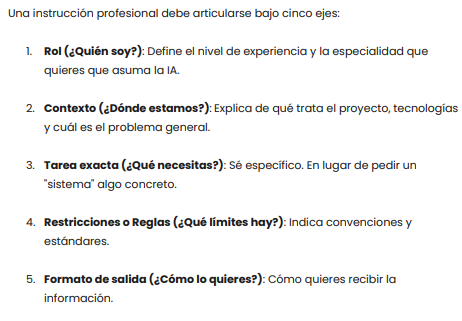

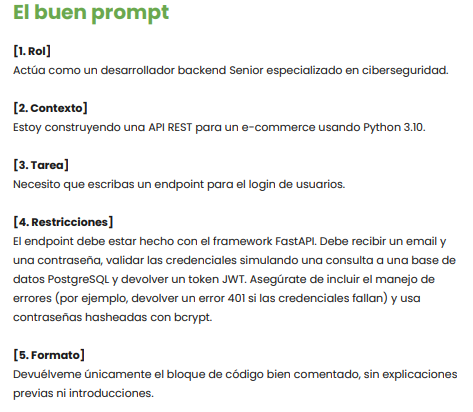

In [ ]:
import google.generativeai as genai

genai.configure(api_key=API_KEY)

model = genai.GenerativeModel("models/gemini-2.5-flash")

response = model.generate_content("""
Eres un Product Manager senior especializado en apps
de entretenimiento con experiencia en gestión de crisis
de usuarios.

Contexto:
Tenemos una app de venta de entradas para cines en Play Store.
Estamos recibiendo reseñas negativas porque los usuarios reportan
que sus entradas compradas con Yape aparecen como canjeadas
sin haberlas usado.

Tarea:
Analiza esta reseña de un usuario y genera un plan de acción
para responder y resolver el problema.

Reseña: "Cineplanet, esto es inaceptable. Compré 2 entradas con
la promo Yape y el sistema indica que fueron canjeadas sin que yo
las usara. Luego esas mismas butacas aparecieron ocupadas por
otras personas. Exijo una explicación y solución inmediata."

Restricciones:
- La respuesta al usuario debe ser empática y profesional
- No prometas soluciones que no puedes garantizar
- Máximo 3 pasos en el plan de acción

Formato de salida:
1. Respuesta pública para Play Store
2. Plan de acción interno (3 pasos)
3. Prioridad del problema: Alta / Media / Baja
""")
print(response.text)

Aquí tienes el análisis y el plan de acción como Product Manager senior.

---

**1. Respuesta pública para Play Store**

"Estimado usuario,

Lamentamos enormemente y de corazón la situación tan frustrante e inaceptable que nos describes con tus entradas compradas con la promo Yape. Entendemos perfectamente tu indignación al ver tus entradas marcadas como canjeadas sin haberlas usado y, peor aún, tus butacas ocupadas por otras personas. Esto no refleja en absoluto el estándar de servicio que nos esforzamos por ofrecer.

Queremos asegurarte que estamos tomando este reporte con la máxima seriedad y urgencia. Para poder investigar a fondo tu caso, identificar lo sucedido y brindarte una solución concreta, te pedimos por favor que nos contactes directamente a través de nuestro centro de ayuda en nuestra web o app, o por mensaje directo con los detalles de tu compra (número de pedido, fecha, sala, y correo electrónico o número de teléfono asociado a la compra).

Nuestro equipo de soporte est

### Fine Tuning

Tu lo adaptas con tus datos, por ejemplo en un Banco toma gemini u otro modelo, le da 5000 conversaciones de sus agentes de atención y el modelo responde exactamente como un agente del BCP.

### RAG

Subes documentos de la empresa, el modelo consultas cuando le preguntas, va a responder basado en esos documentos y luego lo olvida.

In [ ]:
import fitz

ruta_pdf = "/content/factura.pdf"

doc = fitz.open(ruta_pdf)
texto_factura = ""

for pagina in doc:
    texto_factura += pagina.get_text()

print(texto_factura)

 
 
D & T NRUTA  
D & T NRUTA S.A.C.  
AV. ANGAMOS ESTE 1049 URB. CERCADO  
SURQUILLO - LIMA - LIMA 
FACTURA ELECTRONICA
RUC: 20610320351 
E001-5785 
Fecha de Emisión
: 21/11/2025
Señor(es)
: NOVAMOTOS SOCIEDAD ANONIMA
CERRADA - NOVAMOTOS S.A.C.  
RUC 
: 20602714382 
Dirección del Cliente 
: JR. ITURREGUI, JOSE MANUEL 950
LIMA-LIMA-SURQUILLO 
Tipo de Moneda
: SOLES 
Observación
: DEPOSITO EN CUENTA  
Forma de pago: Contado
Cantidad
Unidad Medida
Código
Descripción
Valor Unitario
1.00
UNIDAD
66
BATERIA
110.169491
 
Valor de Venta de Operaciones Gratuitas
:
S/ 0.00 
 
 
 
SON: CIENTO TREINTA Y 00/100 SOLES
 
 
 
Sub Total Ventas :
S/ 110.17 
Anticipos :
S/ 0.00 
Descuentos :
S/ 0.00 
Valor Venta :
S/ 110.17 
ISC :
S/ 0.00 
IGV :
S/ 19.83 
Otros Cargos :
S/ 0.00 
Otros Tributos :
S/ 0.00 
Monto de redondeo :
S/ 0.00 
Importe Total :
S/ 130.00 
Esta es una representación impresa de la factura electrónica, generada en el Sistema de SUNAT. Puede
verificarla utilizando su clave SOL.



In [ ]:
def preguntar_factura(pregunta):
    prompt = f"""
    Eres un asistente contable experto.
    Responde la pregunta basándote ÚNICAMENTE en esta factura.
    Si la respuesta no está en la factura, di "No tengo esa información".

    Factura:
    {texto_factura}

    Pregunta: {pregunta}
    """

    response = model.generate_content(prompt)
    print(f"Pregunta: {pregunta}")
    print(f"Respuesta: {response.text}")
    print("---")

# Prueba con preguntas
preguntar_factura("¿Cuál es el número de la factura?")
preguntar_factura("¿Cuál es el monto total?")
preguntar_factura("¿A nombre de quién está la factura?")

Pregunta: ¿Cuál es el número de la factura?
Respuesta: El número de la factura es E001-5785.
---
Pregunta: ¿Cuál es el monto total?
Respuesta: El monto total es S/ 130.00.
---
Pregunta: ¿A nombre de quién está la factura?
Respuesta: La factura está a nombre de NOVAMOTOS SOCIEDAD ANONIMA CERRADA - NOVAMOTOS S.A.C.
---
